In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json

In [89]:
df  = pd.read_csv("/home/sven/coding/python/TabSCM/Interventions/adult/Interventions.csv")


with open(f"../data/adult/info.json") as f:
         INFO = json.load(f)

In [90]:
# Sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# DiCE imports
import dice_ml
from dice_ml.utils import helpers  # helper functions

In [7]:
dataset = helpers.load_adult_income_dataset()
adult_info = helpers.get_adult_data_info()

target = dataset["income"]
train_dataset, test_dataset, y_train, y_test = train_test_split(dataset,
                                                                target,
                                                                test_size=0.2,
                                                                random_state=0,
                                                                stratify=target)
x_train = train_dataset.drop('income', axis=1)
x_test = test_dataset.drop('income', axis=1)

In [91]:
X_train = pd.read_csv("../data/adult/train.csv")
x_test = pd.read_csv("../data/adult/test.csv")

#### drop fnlwgt, captial.gain, capital.loss


X_train = X_train.drop(labels=['fnlwgt', 'capital.gain', 'capital.loss'],axis=1)
x_test= x_test.drop(labels=['fnlwgt', 'capital.gain', 'capital.loss'],axis=1)

df = df.drop(labels=['fnlwgt', 'capital.gain', 'capital.loss'],axis=1)

In [ ]:
{
    "0": 35, 
    "3": " Masters",
    "7": " White",
    "8": " Male",
    "12": " United-States",
    "13": " >50K"
}

In [92]:
cols_to_change = ['workclass','marital.status','occupation','relationship','hours.per.week']

In [143]:
x_test[(x_test['age'] == 35)  & (x_test['education'] == ' Masters') & (x_test['race']==' White') & (x_test['sex']==" Male") & (x_test["native.country"]==" United-States")]

,age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
656,35.0,Federal-gov,Masters,Married-civ-spouse,Exec-managerial,Husband,White,Male,50.0,United-States,>50K
719,35.0,Private,Masters,Married-civ-spouse,Exec-managerial,Husband,White,Male,48.0,United-States,>50K
1360,35.0,Private,Masters,Married-civ-spouse,Exec-managerial,Husband,White,Male,50.0,United-States,>50K
2258,35.0,Private,Masters,Married-spouse-absent,Protective-serv,Not-in-family,White,Male,40.0,United-States,<=50K
2581,35.0,Local-gov,Masters,Married-civ-spouse,Prof-specialty,Husband,White,Male,45.0,United-States,>50K
2972,35.0,Private,Masters,Married-civ-spouse,Prof-specialty,Husband,White,Male,50.0,United-States,>50K
4999,35.0,Private,Masters,Married-civ-spouse,Adm-clerical,Husband,White,Male,45.0,United-States,>50K
5321,35.0,State-gov,Masters,Never-married,Adm-clerical,Not-in-family,White,Male,40.0,United-States,<=50K
7305,35.0,Private,Masters,Married-civ-spouse,Prof-specialty,Husband,White,Male,50.0,United-States,<=50K
9847,35.0,Private,Masters,Married-civ-spouse,Exec-managerial,Husband,White,Male,45.0,United-States,<=50K


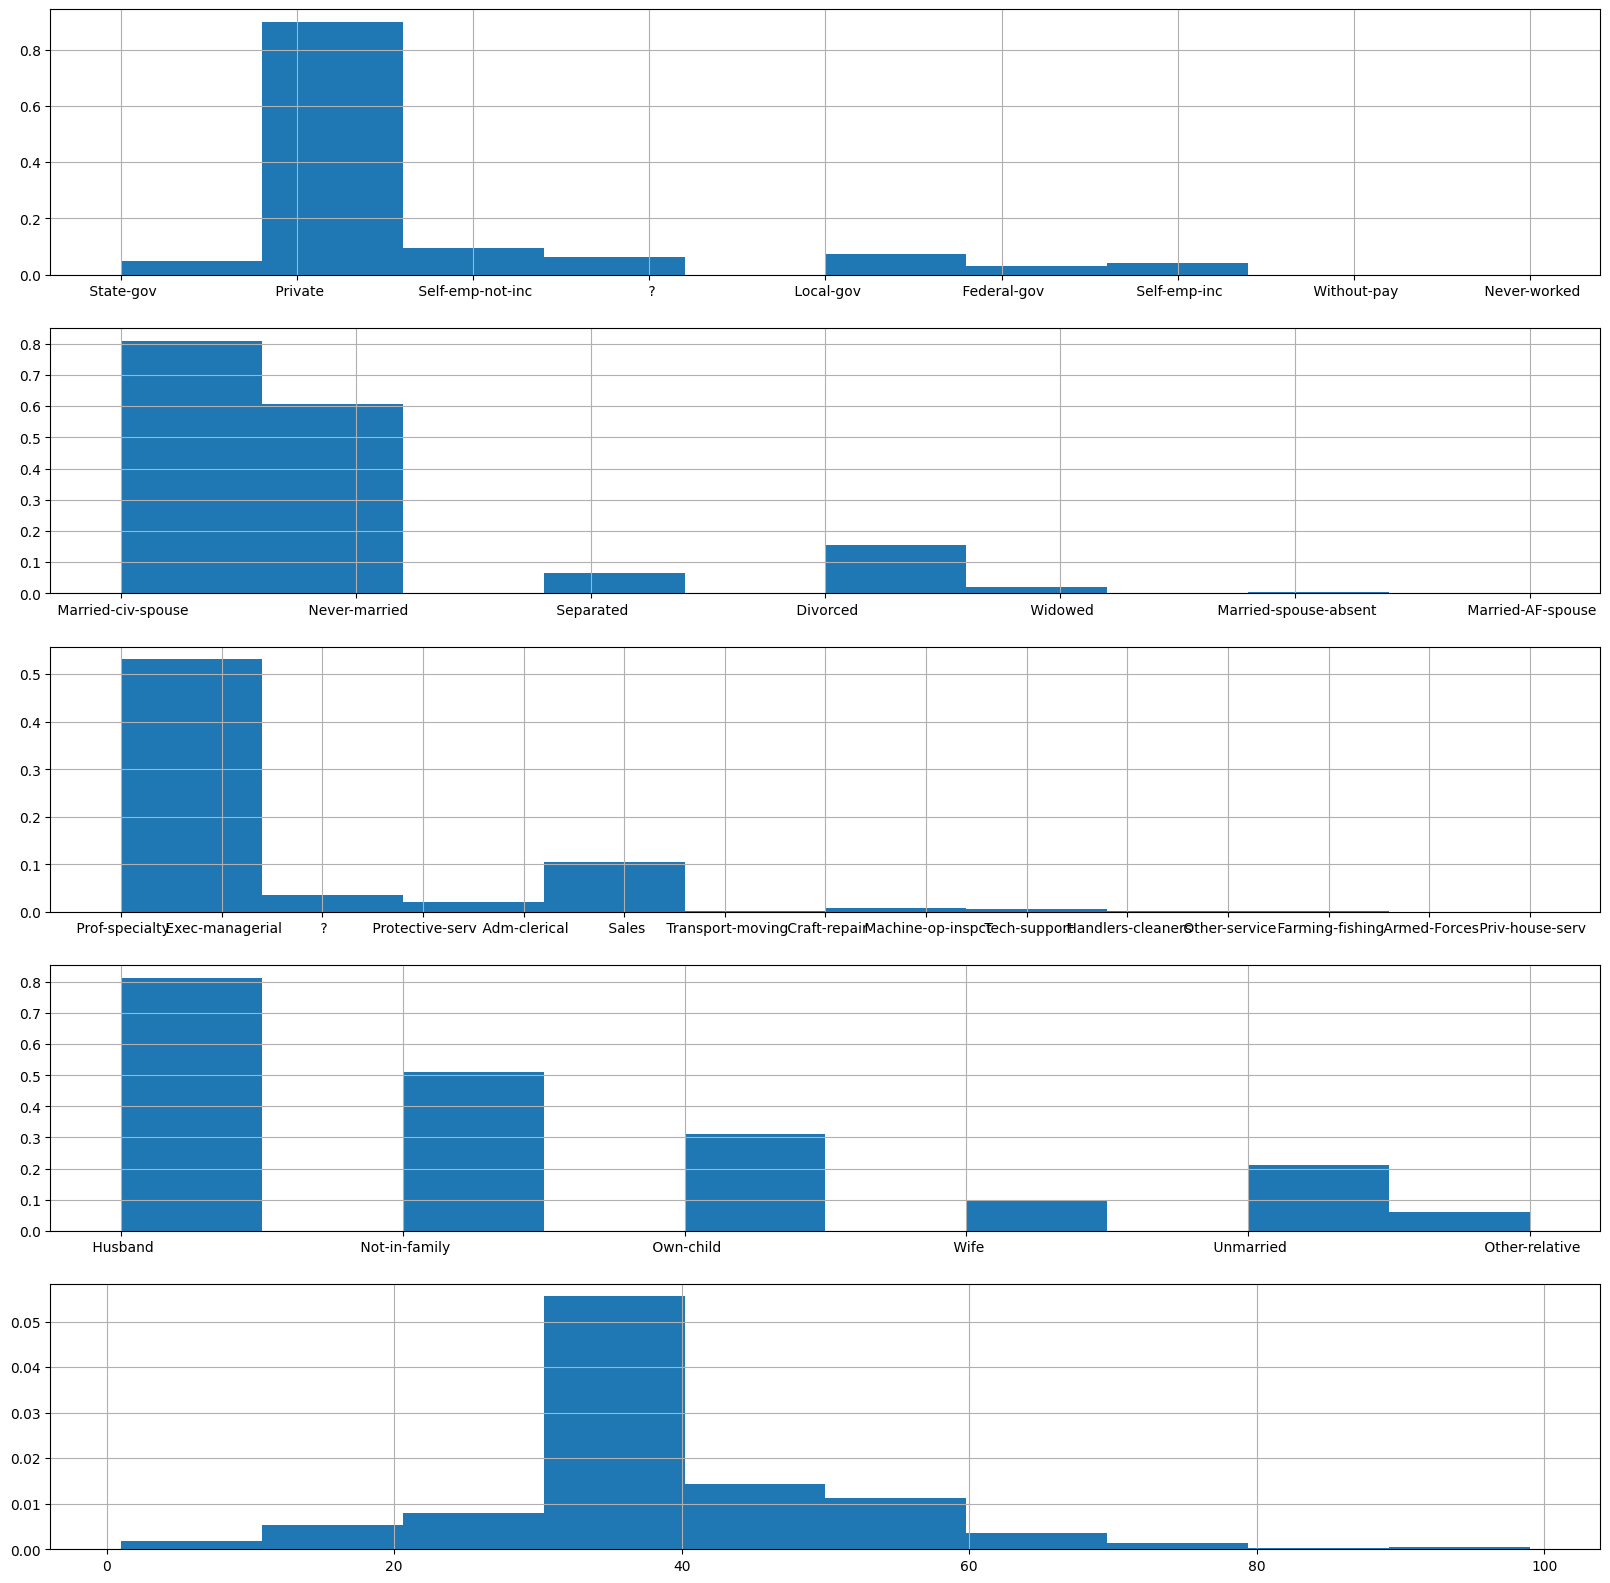

In [182]:
fig, ax = plt.subplots(figsize=(20,20),ncols=1,nrows=len(cols_to_change))
for i,col in enumerate(cols_to_change):
    try:
        df[col].hist(ax=ax[i],density=True)
    except:
        continue

In [95]:
target = X_train['income']

#X_train = X_train.drop(labels='income',axis=1)

In [96]:
X_train = X_train.drop(labels='education.num',axis=1)

In [ ]:
import numpy as np

tmp = np.zeros(len(target))

for i,val in enumerate(X_train['income']):
    if val == " <=50K":
        tmp[i] = 0
    else:
        tmp[i] = 1


target = pd.Series(tmp)



7        1.0
8        1.0
9        1.0
10       1.0
11       1.0
        ... 
32539    1.0
32545    1.0
32554    1.0
32557    1.0
32560    1.0
Length: 7841, dtype: float64

In [118]:
target.shape

(32561,)

In [103]:
X_train.shape

(32561, 11)

In [121]:
X_train = X_train.drop(labels='income',axis=1)

In [123]:
numerical = ["age", "hours_per_week"]
categorical = X_train.columns.difference(numerical)
print(categorical)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

transformations = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical)])

# Append classifier to preprocessing pipeline.
# Now we have a full prediction pipeline.
clf = Pipeline(steps=[('preprocessor', transformations),
                      ('classifier', RandomForestClassifier())])
model = clf.fit(X_train, target)

Index(['education', 'hours.per.week', 'marital.status', 'native.country',
       'occupation', 'race', 'relationship', 'sex', 'workclass'],
      dtype='str')


In [124]:
X_train['income'] = target

In [125]:
d = dice_ml.Data(dataframe=X_train, continuous_features=['age', 'hours.per.week'],outcome_name='income')

In [248]:
m = dice_ml.Model(model=model, backend="sklearn")

exp = dice_ml.Dice(d, m, method="random")

In [134]:
x_test = x_test.drop(labels='education.num', axis=1)

In [144]:
query = x_test.iloc[2258:2259]
query = query.drop(labels='income',axis=1)

In [327]:
query

,age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country
2258,35.0,Private,Masters,Married-spouse-absent,Protective-serv,Not-in-family,White,Male,40.0,United-States


In [328]:
query.to_csv("query.csv",index=False)

In [221]:
len(df)

32561

In [249]:
e1 = exp.generate_counterfactuals(query, total_CFs=32561, desired_class="opposite",features_to_vary=["occupation","marital.status","relationship","hours.per.week","workclass"])
e1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:03<00:00,  3.14s/it]

Query instance (original outcome : 0.0)


,age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
0,35.0,Private,Masters,Married-spouse-absent,Protective-serv,Not-in-family,White,Male,40.0,United-States,0.0



Diverse Counterfactual set (new outcome: 1.0)


,age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
0,-,-,-,Separated,-,-,-,-,-,-,1.0
1,-,-,-,Married-civ-spouse,-,-,-,-,-,-,1.0
2,-,-,-,-,-,Husband,-,-,-,-,1.0
3,-,-,-,-,Exec-managerial,-,-,-,-,-,1.0
4,-,-,-,Married-civ-spouse,Prof-specialty,-,-,-,-,-,1.0
...,...,...,...,...,...,...,...,...,...,...,...
215,-,Self-emp-not-inc,-,-,Tech-support,Husband,-,-,-,-,1.0
216,-,-,-,Married-civ-spouse,Adm-clerical,-,-,-,13.9,-,1.0
217,-,-,-,Separated,Tech-support,-,-,-,46.2,-,1.0
218,-,-,-,Widowed,-,Husband,-,-,64.5,-,1.0


In [250]:
cf_dice = e1.cf_examples_list[0].final_cfs_df

In [246]:
cf_dice_KDTREE = e1.cf_examples_list[0].final_cfs_df

ftv = ["workclass","occupation","marital.status","relationship","hours.per.week"]



In [244]:
cf_dice

,age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
3359,35.0,Private,Masters,Never-married,Exec-managerial,Not-in-family,White,Male,40.0,United-States,1.0
22978,35.0,Private,Masters,Separated,Prof-specialty,Not-in-family,White,Male,40.0,United-States,1.0
26535,35.0,Private,Masters,Married-civ-spouse,Exec-managerial,Husband,White,Male,40.0,United-States,1.0
21013,35.0,Private,Masters,Married-civ-spouse,Prof-specialty,Husband,White,Male,40.0,United-States,1.0
28899,35.0,Private,Masters,Married-civ-spouse,Sales,Husband,White,Male,40.0,United-States,1.0
198,35.0,Private,Masters,Married-civ-spouse,Prof-specialty,Other-relative,White,Male,40.0,United-States,1.0
20052,35.0,Private,Masters,Never-married,Prof-specialty,Not-in-family,White,Male,45.0,United-States,1.0
5614,35.0,Private,Masters,Never-married,Craft-repair,Not-in-family,White,Male,50.0,United-States,1.0
31903,35.0,Local-gov,Masters,Married-civ-spouse,Prof-specialty,Husband,White,Male,40.0,United-States,1.0
4311,35.0,Self-emp-not-inc,Masters,Married-civ-spouse,Sales,Husband,White,Male,40.0,United-States,1.0


In [235]:
df['hours.per.week'] = df["hours.per.week"].astype('O')
cf_dice['hours.per.week'] = cf_dice["hours.per.week"].astype('O')

In [308]:
color = ["#4a0000" , "#808080" , "#d8a6a6" ]

workclass
0 0
occupation
1 0
marital.status
0 1
relationship
3 1
hours.per.week
4 1
1


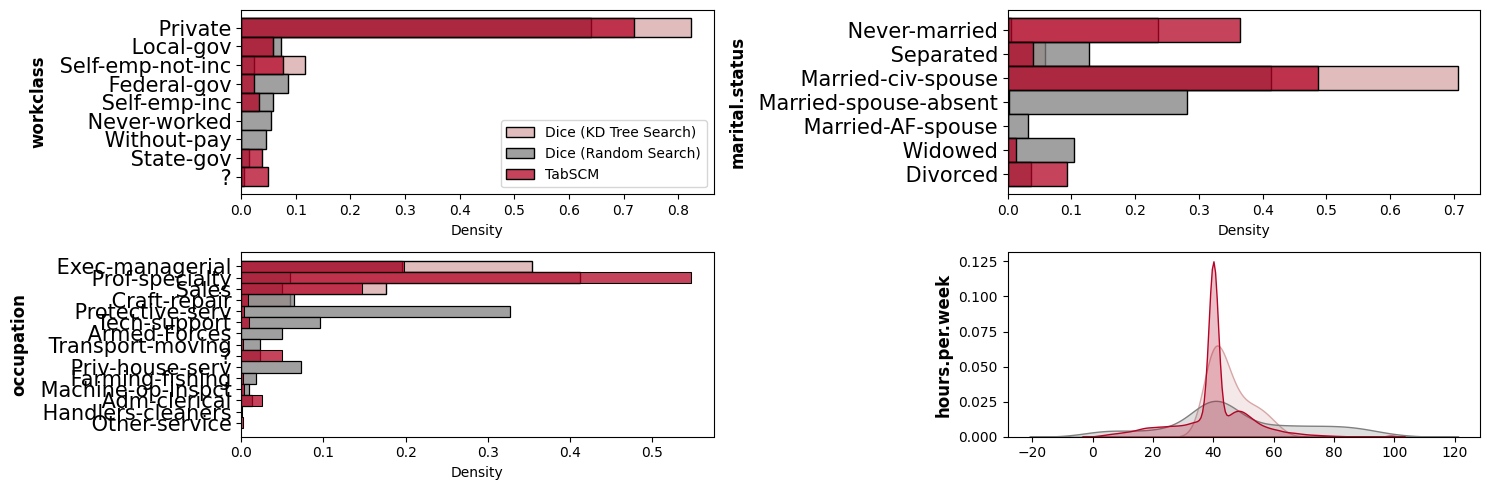

In [386]:
fig, ax = plt.subplots(figsize=(15,5),ncols=2,nrows=2)
j=0
for i,col in enumerate(ftv):
    print(col)
    if i == 2:
        i=0
        j=1
    print(i,j)
    if col == 'relationship':
        continue
    try:
        #cf_dice[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Dice')
        if col == "hours.per.week":
            print(1)
            i=1
            sns.kdeplot(data=cf_dice_KDTREE,x=col,ax=ax[i,j],label='Dice KDTree',color=color[2],fill=True)
            sns.kdeplot(data=cf_dice,x=col,ax=ax[i,j],label='Dice Random',color=color[1],fill=True)

            #cf_dice[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Tabscm')
            #df[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Tabscm')
            sns.kdeplot(data=df,x=col,ax=ax[i,j],label='TabSCM',color='#b40426',fill=True)
            ax[i,j].set_ylabel(col, fontsize=12, weight='bold')
            ax[i,j].set_xlabel("")

        else:
            sns.histplot(data=cf_dice_KDTREE,y=col,ax=ax[i,j],stat="density", discrete=True,label='Dice (KD Tree Search)',color=color[2])
            sns.histplot(data=cf_dice,y=col,ax=ax[i,j],stat="density", discrete=True,label='Dice (Random Search)', color=color[1])
            sns.histplot(data=df,y=col,ax=ax[i,j],stat="density", discrete=True,label='TabSCM',color='#b40426')
            ax[i,j].tick_params(axis='y', labelsize=15)
            ax[i,j].set_ylabel(col, fontsize=12, fontweight='bold')
            #ticks_to_show = [0, 1,2]

        #df[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Tabscm')
        if i == 0 and j ==0:
            ax[0,0].legend()
    except:
        continue

fig.tight_layout()

In [381]:
fig.savefig('Counterfactual.pdf',bbox_inches='tight')

1


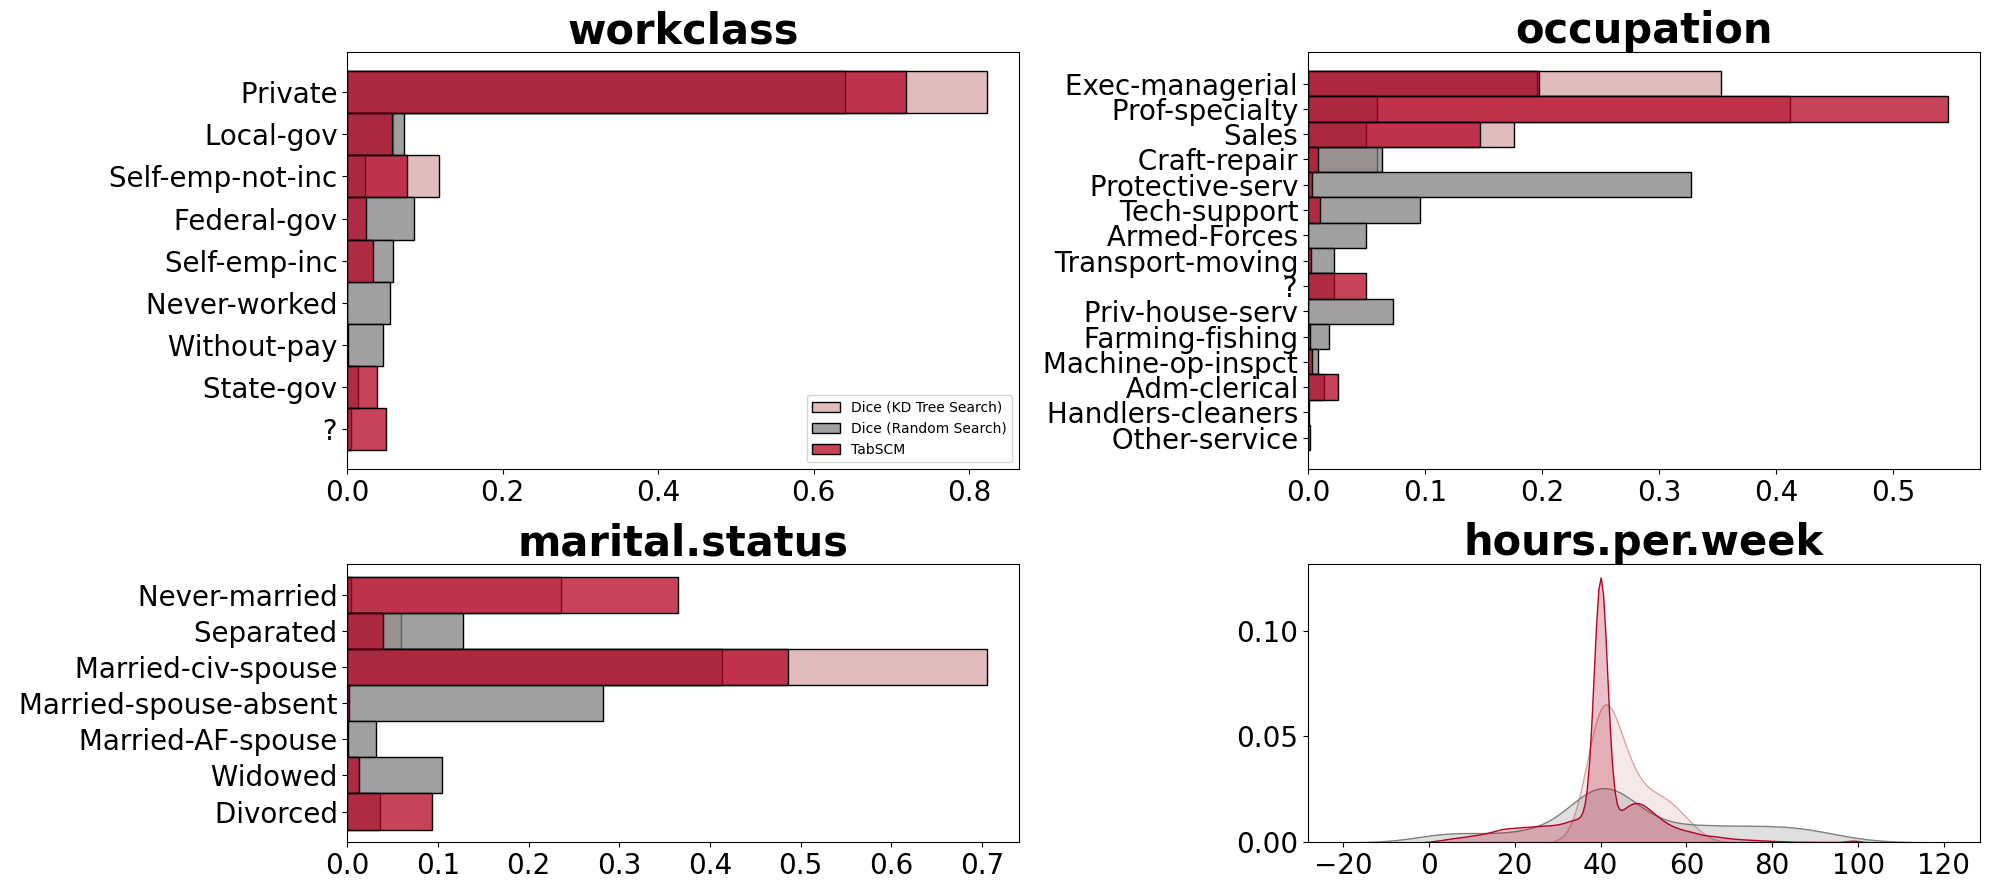

In [420]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Create the figure
fig = plt.figure(figsize=(20, 9))

# 2. Define the grid (2 rows, 2 columns)
# height_ratios=[1, 2] makes the second row twice the height of the first
gs = gridspec.GridSpec(nrows=2, ncols=2, height_ratios=[1.5, 1])

# 3. Assign the individual plots
ax1 = fig.add_subplot(gs[0, 0]) # Row 0, Col 0
ax2 = fig.add_subplot(gs[0, 1]) # Row 0, Col 1
ax3 = fig.add_subplot(gs[1, 0]) # Row 1, Col 0
ax4 = fig.add_subplot(gs[1, 1]) # Row 1, Col 1

# Add some labels to visualize
for i, ax in enumerate([ax1, ax2, ax3, ax4], 1):
    ax.set_title(f"Plot {i}")


AXES= [ax1,ax2,ax3,ax4]

for i,col in enumerate(ftv):
    if col == 'relationship':
        continue
    try:
        #cf_dice[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Dice')
        if col == "hours.per.week":
            print(1)
            i=3
            sns.kdeplot(data=cf_dice_KDTREE,x=col,ax=AXES[i],label='Dice KDTree',color=color[2],fill=True)
            sns.kdeplot(data=cf_dice,x=col,ax=AXES[i],label='Dice Random',color=color[1],fill=True)

            #cf_dice[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Tabscm')
            #df[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Tabscm')
            sns.kdeplot(data=df,x=col,ax=AXES[i],label='TabSCM',color='#b40426',fill=True)
            AXES[i].set_title(col, fontsize=30, weight='bold')
            AXES[i].tick_params(axis='both', labelsize=20)
            AXES[i].set_xlabel("")
            AXES[i].set_ylabel("")

        else:
            sns.histplot(data=cf_dice_KDTREE,y=col,ax=AXES[i],stat="density", discrete=True,label='Dice (KD Tree Search)',color=color[2])
            sns.histplot(data=cf_dice,y=col,ax=AXES[i],stat="density", discrete=True,label='Dice (Random Search)', color=color[1])
            sns.histplot(data=df,y=col,ax=AXES[i],stat="density", discrete=True,label='TabSCM',color='#b40426')
            AXES[i].tick_params(axis='y', labelsize=20)
            AXES[i].tick_params(axis='x', labelsize=20)

            AXES[i].set_title(col, fontsize=30, fontweight='bold')
            AXES[i].set_ylabel('')
            AXES[i].set_xlabel('')
            #ticks_to_show = [0, 1,2]

        #df[col].hist(ax=ax[i],density=True,alpha=0.4,edgecolor='black',label='Tabscm')
        AXES[0].legend()
    except:
        continue



plt.tight_layout()
plt.show()

In [421]:
fig.savefig('Counterfactual_newsize.pdf',bbox_inches='tight')